In [1]:
"""
Reproduce the bar chart from the manuscript.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pingouin as pg
from scipy.stats import t as t_dist
from scipy import stats
import matplotlib.patches as patches
import seaborn as sns
# Paths relative to this script
# ROOT = Path.cwd()
# DATA = ROOT / "figures"
# FIGURES = ROOT / "figures"
# FIGURES.mkdir(exist_ok=True)
ROOT = Path.cwd()
DATA = ROOT / "figures"
colors = [(0, 48, 73),(214, 40, 40),(247, 127, 0),(252, 191, 73),(234, 226, 183),(148, 210, 189),
          (10, 147, 150),(17, 130, 0),]
colorz = []
for x in colors:
    colorz.append((x[0]/255,x[1]/255,x[2]/255))
    
colors1 = [(0, 48, 73),(214, 40, 40),(0, 48, 73),(214, 40, 40),(0, 48, 73),(214, 40, 40),
          (0, 48, 73),(214, 40, 40),]
colorz1 = []
for x in colors1:
    colorz1.append((x[0]/255,x[1]/255,x[2]/255))
    
def simple_beeswarm2(y, nbins=None, width=1.):
    """
    Returns x coordinates for the points in ``y``, so that plotting ``x`` and
    ``y`` results in a bee swarm plot.
    """
    y = np.asarray(y)
    if nbins is None:
        # nbins = len(y) // 6
        nbins = np.ceil(len(y) / 6).astype(int)
    # Get upper bounds of bins
    x = np.zeros(len(y))
    nn, ybins = np.histogram(y, bins=nbins)
    nmax = nn.max()
    #Divide indices into bins
    ibs = []#np.nonzero((y>=ybins[0])*(y<=ybins[1]))[0]]
    for ymin, ymax in zip(ybins[:-1], ybins[1:]):
        i = np.nonzero((y>ymin)*(y<=ymax))[0]
        ibs.append(i)
    # Assign x indices
    dx = width / (nmax // 2)
    for i in ibs:
        yy = y[i]
        if len(i) > 1:
            j = len(i) % 2
            i = i[np.argsort(yy)]
            a = i[j::2]
            b = i[j+1::2]
            x[a] = (0.5 + j / 3 + np.arange(len(b))) * dx
            x[b] = (0.5 + j / 3 + np.arange(len(b))) * -dx
    return x    

def dunnett_test(samples, control, alternative='two-sided'):
    """
    Manual implementation of Dunnett's test for comparing multiple 
    treatment groups against a single control group.
    
    Parameters:
    -----------
    samples : list of array_like
        List of treatment group samples
    control : array_like
        Control group sample
    alternative : str
        'two-sided', 'less', or 'greater'
    
    Returns:
    --------
    statistic : ndarray
        Test statistics for each treatment vs control
    pvalues : ndarray
        P-values for each treatment vs control
    """
    
    # Convert to arrays
    control = np.asarray(control)
    samples = [np.asarray(sample) for sample in samples]
    
    n_groups = len(samples) + 1  # +1 for control
    n_control = len(control)
    n_treatments = [len(s) for s in samples]
    
    # Group means
    mean_control = np.mean(control)
    means_treatments = [np.mean(s) for s in samples]
    
    # Variances for each group
    var_control = np.var(control, ddof=1)
    vars_treatments = [np.var(s, ddof=1) for s in samples]
    
    # Pooled variance (assuming equal variance across groups)
    # That's a key assumption of Dunnett's test
    all_values = np.concatenate([control] + samples)
    grand_mean = np.mean(all_values)
    
    # Calculate Mean Square Error (within-group variance)
    ss_within = 0
    df_within = 0
    for group in [control] + samples:
        ss_within += np.sum((group - np.mean(group))**2)
        df_within += len(group) - 1
    
    ms_within = ss_within / df_within
    
    # Calculate standard error for each comparison
    # SE = sqrt(MS_within * (1/n_control + 1/n_treatment))
    se_values = []
    for n_treat in n_treatments:
        se = np.sqrt(ms_within * (1/n_control + 1/n_treat))
        se_values.append(se)
    
    # Calculate t-statistics
    t_stats = []
    for mean_treat, se in zip(means_treatments, se_values):
        t_stat = (mean_treat - mean_control) / se
        t_stats.append(t_stat)
    
    # Critical values and p-values
    # For Dunnett's test, we need the t-distribution with df = df_within
    # and adjust for multiple comparisons
    
    if alternative == 'two-sided':
        # For two-sided test
        pvalues = [2 * (1 - t_dist.cdf(abs(t), df=df_within)) 
                   for t in t_stats]
    elif alternative == 'less':
        pvalues = [t_dist.cdf(t, df=df_within) for t in t_stats]
    elif alternative == 'greater':
        pvalues = [1 - t_dist.cdf(t, df=df_within) for t in t_stats]
    else:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'")
    
    # Bonferroni correction for multiple comparisons (conservative)
    # For proper Dunnett, you'd use the specialized distribution,
    # but Bonferroni is a safe approximation
    pvalues_bonferroni = np.array(pvalues) * n_groups
    pvalues_bonferroni = np.minimum(pvalues_bonferroni, 1.0)
    
    return np.array(t_stats), pvalues_bonferroni

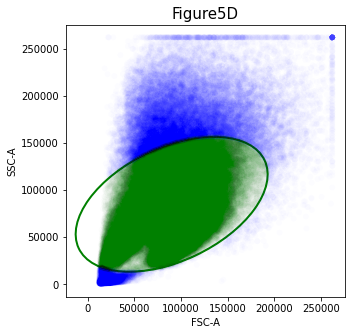

bonferoni tukey test
  Contrast        A        B  Paired  Parametric           T  dof alternative  \
0    group       aH   aH_dox   False        True   -4.271445  4.0   two-sided   
1    group       aH  control   False        True   21.378378  4.0   two-sided   
2    group       aH      dox   False        True   20.888459  4.0   two-sided   
3    group   aH_dox  control   False        True  121.270224  4.0   two-sided   
4    group   aH_dox      dox   False        True  112.563711  4.0   two-sided   
5    group  control      dox   False        True   -4.250935  4.0   two-sided   

          p-unc        p-corr p-adjust       BF10     hedges  
0  1.293527e-02  7.761163e-02     bonf      4.351  -2.790096  
1  2.831025e-05  1.698615e-04     bonf    292.644  13.964298  
2  3.103981e-05  1.862389e-04     bonf    273.479  13.644284  
3  2.772922e-08  1.663753e-07     bonf  5.141e+04  79.213379  
4  3.735332e-08  2.241199e-07     bonf  4.112e+04  73.526308  
5  1.314826e-02  7.888959e-02    

/home/ryanodine/codebook/envirtual/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: divide by zero encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/home/ryanodine/codebook/envirtual/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: divide by zero encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)
/home/ryanodine/codebook/envirtual/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: divide by zero encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/home/ryanodine/codebook/envirtual/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: divide by zero encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)


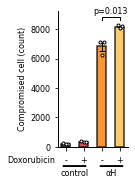

In [2]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig5D_data.parquet"
df = pd.read_parquet(Rawdata)
fig,ax = plt.subplots(figsize=(5,5))
x,y = df['FSC-A'],df['SSC-A']
# The ellipse
g_ell_center,g_ell_width,g_ell_height,angle = (90000, 85000),220000,120000,25.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle,sin_angle = np.cos(np.radians(180.-angle)),np.sin(np.radians(180.-angle))

xc,yc = x - g_ell_center[0],y - g_ell_center[1]

xct,yct = xc * cos_angle - yc * sin_angle,xc * sin_angle + yc * cos_angle 

rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.01, alpha =0.01)
ax.set_title('Figure5D', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
plt.show()
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
df = df.loc[(df['CBA NIR-A'] > 7000)]
df = df.groupby('condition')['CBA NIR-A'].describe().T
df = pd.DataFrame([(group, val) for group, vals in df.items() for val in vals[:1]],
                  columns=['group', 'value'])
df['group'] = df['group'].str[:-1]

tukey = pg.pairwise_tests(dv='value', between='group', data=df, padjust='bonf')   
print('bonferoni tukey test'), print(tukey)

means, sems = df.groupby('group')['value'].mean(), df.groupby('group')['value'].sem()
order = ['control', 'dox', 'aH', 'aH_dox',]
means,sems = means.reindex(order), sems.reindex(order)

w, x = 0.5, [1,2,3,4]
fig, ax = plt.subplots(figsize=(1.25,2.5))
ax.bar(x,height=means,yerr=sems,capsize=10,width=w,tick_label=[" ", " ", ' ', ' '],color=colorz,
       alpha = 0.8,edgecolor=(0,0,0,1),linewidth=1.5,error_kw=dict(lw=1, capsize=3, capthick=1))
x1 = simple_beeswarm2(df[df['group'] == 'control']['value'], width=0.25)
ax.plot(x1+1., df[df['group'] == 'control']['value'], '.', color ='w',markeredgecolor='black')
x2 = simple_beeswarm2(df[df['group'] == 'dox']['value'], width=0.25)
ax.plot(x2+2., df[df['group'] == 'dox']['value'], '.', color ='w',markeredgecolor='black')
x3 = simple_beeswarm2(df[df['group'] == 'aH']['value'], width=0.25)
ax.plot(x3+3., df[df['group'] == 'aH']['value'], '.', color ='w',markeredgecolor='black')
x4 = simple_beeswarm2(df[df['group'] == 'aH_dox']['value'], width=0.25)
ax.plot(x4+4., df[df['group'] == 'aH_dox']['value'], '.', color ='w',markeredgecolor='black')
ax.tick_params(top=False,bottom=True,left=True,right=False,labelleft=True,labelbottom=True)
plt.ylabel('Compromised cell (count)',fontsize=8)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
tick_len, pad, pvp = 150, 100, [9800,8800,10800]
ax.plot([3, 3, 4, 4], [pvp[1] - tick_len, pvp[1], pvp[1], pvp[1] - tick_len], c="black",linewidth=1)
label2 = f"p={tukey['p-unc'].iloc[0]:.3f}" ### p=0.01 tt, p_bonferroni=.761163e-02
ax.text(3.5, pvp[1] + pad, label2, fontsize=8, va="bottom", ha="center")
ax.text(-0.9, -1200, "Doxorubicin", fontsize=8, va="bottom", ha="center")
ax.text(1, -1200, "-", fontsize=8, va="bottom", ha="center")
ax.text(2, -1200, "+", fontsize=8, va="bottom", ha="center")
ax.text(3, -1200, "-", fontsize=8, va="bottom", ha="center")
ax.text(4, -1200, "+", fontsize=8, va="bottom", ha="center")
ax.text(1.5, -1350, "__", fontsize=24, va="bottom", ha="center")
ax.text(3.5, -1350, "__", fontsize=24, va="bottom", ha="center")
ax.text(1.5, -2100, "control", fontsize=8, va="bottom", ha="center")
ax.text(3.5, -2100, "αH", fontsize=8, va="bottom", ha="center")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_linewidth(1)
# FIGURES = ROOT / "./../figures/"
# outfile = FIGURES / "figure5D.svg"
# plt.savefig(outfile, format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

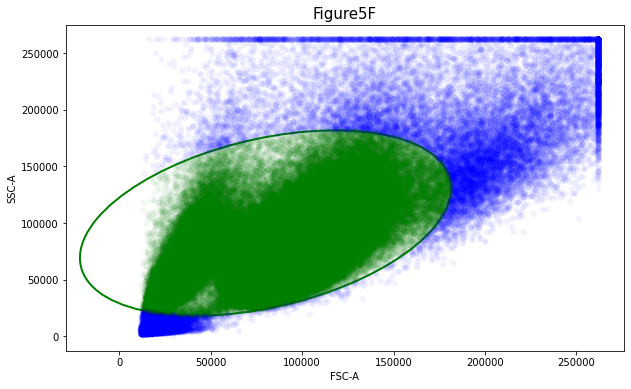

bonferoni tukey test
   Contrast       A       B  Paired  Parametric          T  dof alternative  \
0     group       C    aBCD   False        True  -6.924067  4.0   two-sided   
1     group       C  aBCsiD   False        True  -4.997914  4.0   two-sided   
2     group       C      aD   False        True -21.977634  4.0   two-sided   
3     group       C     apD   False        True -22.828573  4.0   two-sided   
4     group       C   apsiD   False        True  -6.568881  4.0   two-sided   
5     group       C    asiD   False        True -26.246639  4.0   two-sided   
6     group       C      si   False        True   1.907354  4.0   two-sided   
7     group    aBCD  aBCsiD   False        True  -1.238667  4.0   two-sided   
8     group    aBCD      aD   False        True  -7.647455  4.0   two-sided   
9     group    aBCD     apD   False        True  -5.937789  4.0   two-sided   
10    group    aBCD   apsiD   False        True   1.491099  4.0   two-sided   
11    group    aBCD    asiD   F

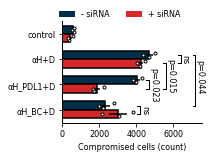

In [3]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig5F_data.parquet"
df = pd.read_parquet(Rawdata)
df = df.loc[(df['CBA NIR-A'] > 0)]
df = df.loc[(df['PE-A'] > 0)]
fig,ax = plt.subplots(figsize=(10,6))

x,y = df['FSC-A'], df['SSC-A']

# The ellipse
g_ell_center,g_ell_width,g_ell_height,angle = (80000, 100000), 220000, 140000, 30.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle, sin_angle = np.cos(np.radians(180.-angle)), np.sin(np.radians(180.-angle))

xc, yc = x - g_ell_center[0], y - g_ell_center[1]

xct, yct = xc * cos_angle - yc * sin_angle, xc * sin_angle + yc * cos_angle 

rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.05, alpha =0.05)
ax.set_title('Figure5F', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
plt.show()
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
df['Dead'] = np.where(df['CBA NIR-A'] > 6000, 1,0)
df = df.loc[(df['Dead'] == 1)]
df = df.groupby('condition')['CBA NIR-A'].describe().T

df = pd.DataFrame([(group, val) for group, vals in df.items() for val in vals[:1]],
                  columns=['group', 'value'])
df['group'] = df['group'].str[:-1]

means, sems = df.groupby('group')['value'].mean(), df.groupby('group')['value'].sem()
order = ['C', 'si', 'aD', 'asiD','apD', 'apsiD','aBCD', 'aBCsiD',]
means, sems = means.reindex(order), sems.reindex(order)

tukey = pg.pairwise_tests(dv='value', between='group', data=df, padjust='bonf')   
print('bonferoni tukey test'),print(tukey)

fig, ax = plt.subplots(figsize=(2.5,1.875))
y_pos = 0,0.5,1.5,2,3,3.5,4.5,5, 
ax.barh(y_pos, means, xerr=sems, color=colorz1, align='center',edgecolor=(0,0,0,1),linewidth=1.5,
        height=0.5)
x1 = simple_beeswarm2(df[df['group'] == 'C']['value'], width=0.25)
ax.plot(df[df['group'] == 'C']['value'],x1, '.', color ='w',markeredgecolor='black')
x2 = simple_beeswarm2(df[df['group'] == 'si']['value'], width=0.25)
ax.plot(df[df['group'] == 'si']['value'],x2+0.5,  '.', color ='w',markeredgecolor='black')
x3 = simple_beeswarm2(df[df['group'] == 'aD']['value'], width=0.25)
ax.plot(df[df['group'] == 'aD']['value'],x3+1.5,  '.', color ='w',markeredgecolor='black')
x4 = simple_beeswarm2(df[df['group'] == 'asiD']['value'], width=0.25)
ax.plot(df[df['group'] == 'asiD']['value'],x4+2,  '.',color ='w',markeredgecolor='black')
x5 = simple_beeswarm2(df[df['group'] == 'apD']['value'], width=0.25)
ax.plot(df[df['group'] == 'apD']['value'],x5+3,  '.',color ='w',markeredgecolor='black')
x6 = simple_beeswarm2(df[df['group'] == 'apsiD']['value'], width=0.25)
ax.plot(df[df['group'] == 'apsiD']['value'],x6+3.5,  '.', color ='w',markeredgecolor='black')
x7 = simple_beeswarm2(df[df['group'] == 'aBCD']['value'], width=0.25)
ax.plot(df[df['group'] == 'aBCD']['value'],x7+4.5,  '.', color ='w',markeredgecolor='black')
x8 = simple_beeswarm2(df[df['group'] == 'aBCsiD']['value'], width=0.25)
ax.plot(df[df['group'] == 'aBCsiD']['value'],x8+5,  '.', color ='w',markeredgecolor='black')
y_pos1 = 0.25,1.75,3.25,4.75,
people = ('control', 'αH+D', 'αH_PDL1+D', 'αH_BC+D',)
ax.set_yticks(y_pos1, labels=people)
ax.tick_params(top=False,bottom=True,left=True,right=False,labelleft=True,labelbottom=True)
ax.invert_yaxis()
ax.set_xlabel('Compromised cells (count)',fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
from matplotlib.patches import Patch
handles = [Patch(facecolor=colorz[0], label='- siRNA'),Patch(facecolor=colorz[1], label='+ siRNA')]
plt.legend(handles=handles,bbox_to_anchor=(0.9, 1.18),ncol=2,fontsize=8,frameon=False,)
ax.get_legend().get_frame().set_facecolor('white')
plt.yticks(fontsize=8)
tick_len, pvp, pad = 150, [6400,4700,4200,5600,7200], 250
ax.plot([pvp[0] - tick_len, pvp[0], pvp[0], pvp[0] - tick_len],[1.5,1.5,2,2],c="black",linewidth=1)
ax.plot([pvp[1] - tick_len, pvp[1], pvp[1], pvp[1] - tick_len],[3,3,3.5,3.5],c="black",linewidth=1)
ax.plot([pvp[2] - tick_len, pvp[2], pvp[2], pvp[2] - tick_len],[4.5,4.5,5,5],c="black",linewidth=1)
ax.plot([pvp[3] - tick_len, pvp[3], pvp[3], pvp[3] - tick_len],[2,2,3.5,3.5],c="black",linewidth=1)
ax.plot([pvp[4] - tick_len, pvp[4], pvp[4], pvp[4] - tick_len],[1.5,1.5,4.5,4.5],c="black",linewidth=1)
label1 = r"ns" ### p_bonferroni=1.000000
label2 = f"p={tukey['p-corr'].iloc[22]:.3f}" ### p_bonferroni=0.023062
label3 = r"ns" ### p_bonferroni=1.000000
label4 = f"p={tukey['p-corr'].iloc[25]:.3f}" ### p_bonferroni=0.014703
label5 = f"p={tukey['p-corr'].iloc[8]:.3f}" ### p_bonferroni=0.043983
ax.text(pvp[0] + pad,1.75,  label1, fontsize=8, va="center", ha="center",rotation=270)
ax.text(pvp[1] + pad,3.25,  label2, fontsize=8, va="center", ha="center",rotation=270)
ax.text(pvp[2] + pad,4.75,  label3, fontsize=8, va="center", ha="center",rotation=270)
ax.text(pvp[3] + pad,2.75,  label4, fontsize=8, va="center", ha="center",rotation=270)
ax.text(pvp[4] + pad,2.75,  label5, fontsize=8, va="center", ha="center",rotation=270)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_linewidth(1)
# FIGURES = ROOT / "./../figures"
# outfile = FIGURES / "figure5F.svg"
# plt.savefig(outfile, format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()

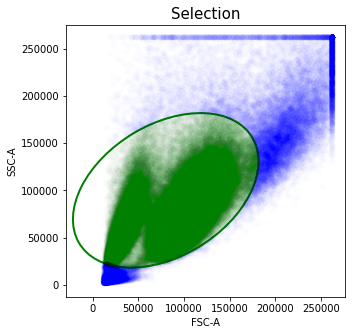

       comparison          t         p       mean1       mean2
0         C vs si  10.499244  0.000465  329.741385  239.535640
1      aD vs asiD   6.526987  0.002846  496.020333  397.403452
2    apD vs apsiD   6.127545  0.003594  488.500985  407.395720
3  aBCD vs aBCsiD   5.237544  0.006351  439.752169  395.660633


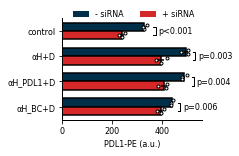

In [4]:
ROOT = Path.cwd()
DATA = ROOT / "./../DATA/"
Rawdata = DATA / "Fig5I_data.parquet"
df = pd.read_parquet(Rawdata)

fig,ax = plt.subplots(figsize=(5,5))

x,y = df['FSC-A'],df['SSC-A']

# The ellipse
g_ell_center, g_ell_width, g_ell_height, angle = (80000, 100000),220000,140000,30.

g_ellipse = patches.Ellipse(g_ell_center, g_ell_width, g_ell_height, angle=angle, fill=False, 
                            edgecolor='green', linewidth=2)
ax.add_patch(g_ellipse)

cos_angle,sin_angle = np.cos(np.radians(180.-angle)), np.sin(np.radians(180.-angle))

xc, yc = x - g_ell_center[0], y - g_ell_center[1]

xct, yct = xc * cos_angle - yc * sin_angle, xc * sin_angle + yc * cos_angle 

rad_cc = (xct**2/(g_ell_width/2.)**2) + (yct**2/(g_ell_height/2.)**2)

# Set the colors. Blue if outside the ellipse, green if inside
colors_array = np.array(['b'] * len(rad_cc))
colors_array[np.where(rad_cc <= 1.)[0]] = 'green'

ax.scatter(df['FSC-A'],df['SSC-A'], c=colors_array,linewidths=0.01, alpha =0.01)
ax.set_title('Selection', fontsize=15)
ax.set_xlabel("FSC-A",fontsize=10)
ax.set_ylabel("SSC-A",fontsize=10)
plt.show()
df['singlecell'] = colors_array
df = df.loc[(df['singlecell'] == 'g')]
df['Dead'] = np.where(df['CBA NIR-A'] > 6000, 1,0)
df = df.loc[(df['Dead'] == 0)]

df = df.groupby('condition')['PE-A'].describe().T
df = pd.DataFrame([(group, val) for group, vals in df.items() for val in vals[1:2]],
                  columns=['group', 'value'])
df['group'] = df['group'].str[:-1]
means, sems = df.groupby('group')['value'].mean(), df.groupby('group')['value'].sem()
order = ['C', 'si', 'aD', 'asiD','apD', 'apsiD','aBCD', 'aBCsiD',]
means, sems = means.reindex(order), sems.reindex(order)

pairs = [(order[i], order[i+1]) for i in range(0, len(order), 2)]

results = []
for g1, g2 in pairs:
    vals1 = df.loc[df['group'] == g1, 'value']
    vals2 = df.loc[df['group'] == g2, 'value']
    tstat, pval = stats.ttest_ind(vals1, vals2)   # two-sided independent t-test
    results.append({
        'comparison': f'{g1} vs {g2}','t': tstat,'p': pval,'mean1': vals1.mean(),
        'mean2': vals2.mean()})
results_df = pd.DataFrame(results)
print(results_df)

fig, ax = plt.subplots(figsize=(2.5,1.875))
y_pos = 0,0.5,1.5,2,3,3.5,4.5,5, 
ax.barh(y_pos, means, xerr=sems, color=colorz1, align='center',edgecolor=(0,0,0,1),linewidth=1.5,
        height=0.5)
x1 = simple_beeswarm2(df[df['group'] == 'C']['value'], width=0.25)
ax.plot(df[df['group'] == 'C']['value'],x1, '.', color ='w',markeredgecolor='black')
x2 = simple_beeswarm2(df[df['group'] == 'si']['value'], width=0.25)
ax.plot(df[df['group'] == 'si']['value'],x2+0.5,  '.', color ='w',markeredgecolor='black')
x3 = simple_beeswarm2(df[df['group'] == 'aD']['value'], width=0.25)
ax.plot(df[df['group'] == 'aD']['value'],x3+1.5,  '.', color ='w',markeredgecolor='black')
x4 = simple_beeswarm2(df[df['group'] == 'asiD']['value'], width=0.25)
ax.plot(df[df['group'] == 'asiD']['value'],x4+2,  '.',color ='w',markeredgecolor='black')
x5 = simple_beeswarm2(df[df['group'] == 'apD']['value'], width=0.25)
ax.plot(df[df['group'] == 'apD']['value'],x5+3,  '.',color ='w',markeredgecolor='black')
x6 = simple_beeswarm2(df[df['group'] == 'apsiD']['value'], width=0.25)
ax.plot(df[df['group'] == 'apsiD']['value'],x6+3.5,  '.', color ='w',markeredgecolor='black')
x7 = simple_beeswarm2(df[df['group'] == 'aBCD']['value'], width=0.25)
ax.plot(df[df['group'] == 'aBCD']['value'],x7+4.5,  '.', color ='w',markeredgecolor='black')
x8 = simple_beeswarm2(df[df['group'] == 'aBCsiD']['value'], width=0.25)
ax.plot(df[df['group'] == 'aBCsiD']['value'],x8+5,  '.', color ='w',markeredgecolor='black')
y_pos1 = 0.25,1.75,3.25,4.75,
people = ('control', 'αH+D', 'αH_PDL1+D', 'αH_BC+D',)
ax.set_yticks(y_pos1, labels=people)
ax.tick_params(top=False,bottom=True,left=True,right=False,labelleft=True,labelbottom=True)
ax.invert_yaxis() 
ax.set_xlabel('PDL1-PE (a.u.)',fontsize=8,)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
from matplotlib.patches import Patch
handles = [Patch(facecolor=colorz[0], label='- siRNA'),Patch(facecolor=colorz[1], label='+ siRNA')]
plt.legend(handles=handles,bbox_to_anchor=(1, 1.15),ncol=2,fontsize=8,frameon=False,)
ax.get_legend().get_frame().set_facecolor('white')
plt.yticks(fontsize=8)
tick_len, pad, pvp = 10, 80, [375,535,530,475,]
ax.plot([pvp[0] - tick_len, pvp[0], pvp[0], pvp[0] - tick_len],[0, 0, 0.5, 0.5],c="black",linewidth=1)
ax.plot([pvp[1] - tick_len, pvp[1], pvp[1], pvp[1] - tick_len],[1.5,1.5,2,2],c="black",linewidth=1)
ax.plot([pvp[2] - tick_len, pvp[2], pvp[2], pvp[2] - tick_len],[3,3,3.5,3.5],c="black",linewidth=1)
ax.plot([pvp[3] - tick_len, pvp[3], pvp[3], pvp[3] - tick_len],[4.5,4.5,5,5],c="black",linewidth=1)
label1 = r"p<0.001" ### p=0.000795
label2 = f"p={results_df['p'].iloc[1]:.3f}" ### p=0.004612
label3 = f"p={results_df['p'].iloc[2]:.3f}" ### p=0.009816
label4 = f"p={results_df['p'].iloc[3]:.3f}" ### p=0.020949
ax.text(pvp[0] + pad,0.25,  label1, fontsize=8, va="center", ha="center",)
ax.text(pvp[1] + pad,1.75,  label2, fontsize=8, va="center", ha="center",)
ax.text(pvp[2] + pad,3.25,  label3, fontsize=8, va="center", ha="center",)
ax.text(pvp[3] + pad,4.75,  label4, fontsize=8, va="center", ha="center",)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
ax.spines["left"].set_linewidth(1)
# FIGURES = ROOT / "./../figures"
# outfile = FIGURES / "figure5I.svg"
# plt.savefig(outfile, format='svg', dpi=300, transparent=True,bbox_inches='tight')
plt.show()